In [2]:
# Task 3 - Data Visualization
# Dataset: IMDB Top 250 Movies

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Professional theme set karo
plt.rcParams["figure.dpi"]       = 150
plt.rcParams["font.family"]      = "DejaVu Sans"
plt.rcParams["axes.spines.top"]  = False
plt.rcParams["axes.spines.right"]= False

# IMDB color palette
IMDB_YELLOW = "#F5C518"
IMDB_BLACK  = "#1A1A1A"
IMDB_GRAY   = "#6D6D6D"

# Data load karo
df = pd.read_csv("../Task1_WebScraping/imdb_top250.csv")
df["Primary_Genre"] = df["Genre"].str.split(",").str[0].str.strip()
df["Decade"]        = (df["Year"] // 10 * 10).astype(str) + "s"
df["Votes_M"]       = (df["Votes"] / 1_000_000).round(2)
df["Director"]      = df["Director"].str.replace("&apos;", "'")

print(" Ready! lets start Data Visualization")

 Ready! lets start Data Visualization


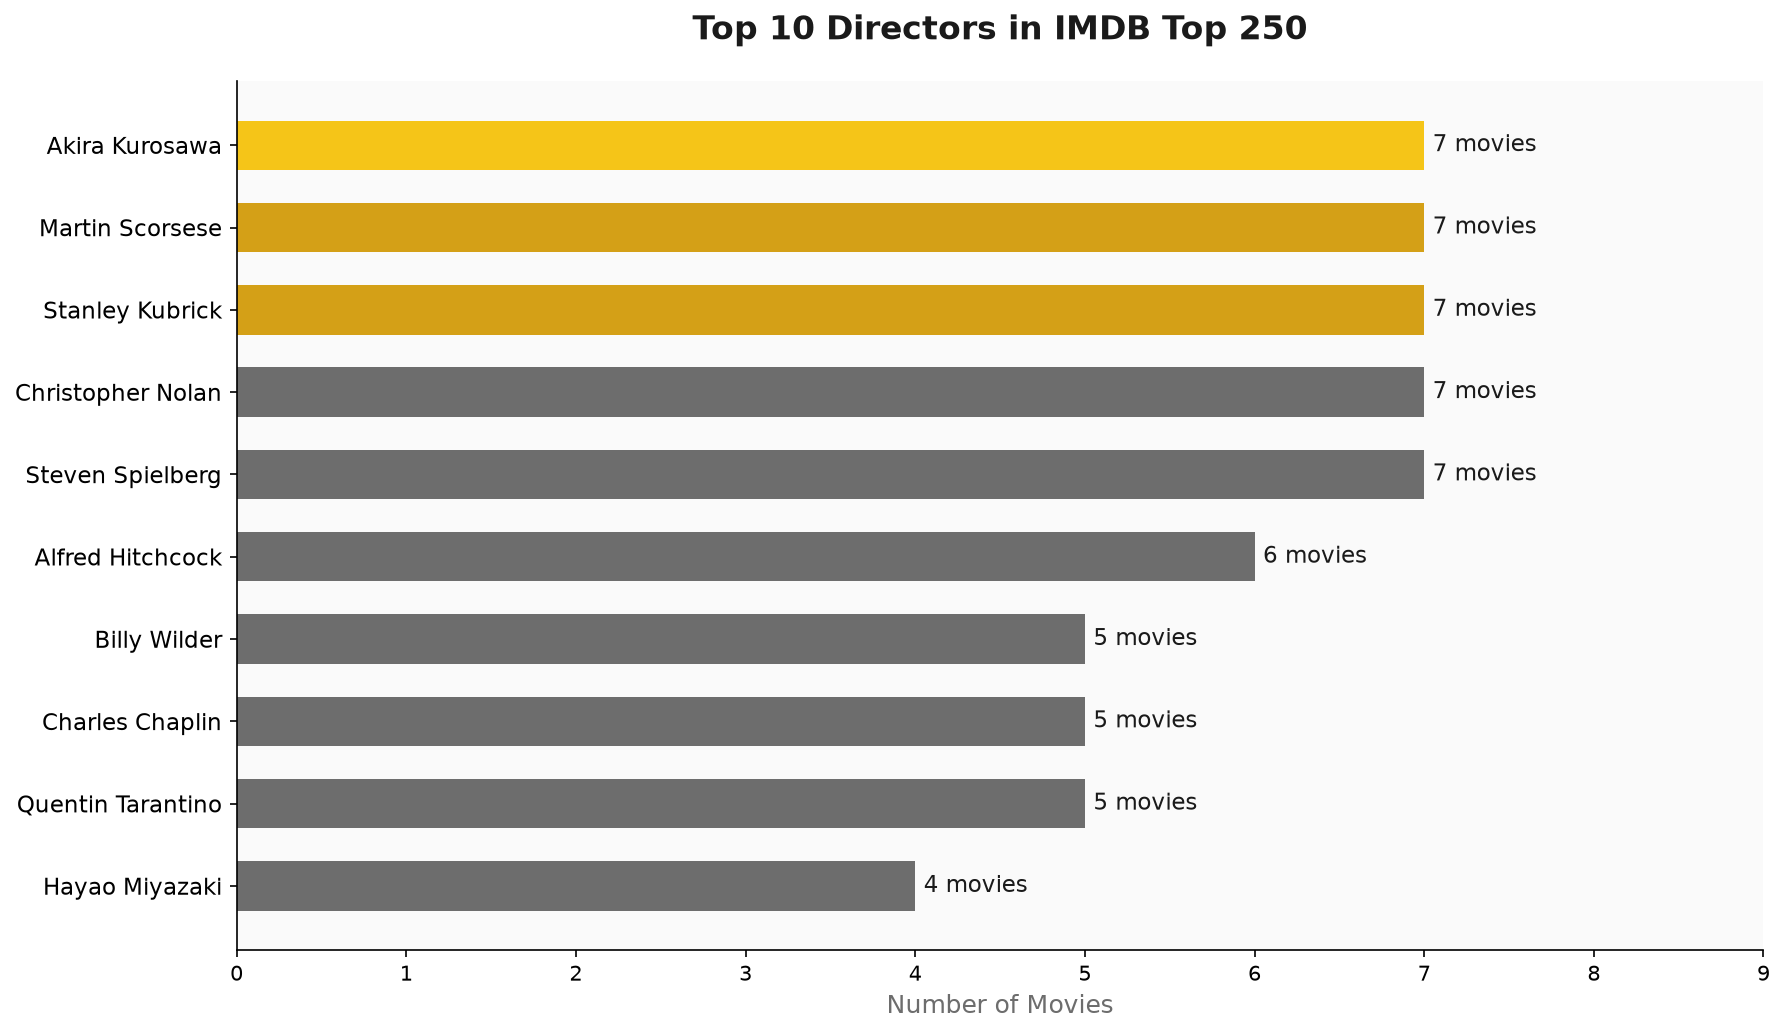

 Chart 1 saved!


In [3]:
# Chart 1 - Top 10 Directors
fig, ax = plt.subplots(figsize=(12, 7))

top_dirs   = df["Director"].value_counts().head(10)
colors     = [IMDB_YELLOW if i == 0 else "#D4A017" if i < 3 else IMDB_GRAY 
              for i in range(len(top_dirs))]

bars = ax.barh(top_dirs.index, top_dirs.values, color=colors, edgecolor="none", height=0.6)

# Value labels
for bar, val in zip(bars, top_dirs.values):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f"{val} movies", va="center", fontsize=11, color=IMDB_BLACK)

# Styling
ax.set_title("Top 10 Directors in IMDB Top 250", 
             fontsize=16, fontweight="bold", pad=20, color=IMDB_BLACK)
ax.set_xlabel("Number of Movies", fontsize=12, color=IMDB_GRAY)
ax.set_xlim(0, max(top_dirs.values) + 2)
ax.invert_yaxis()
ax.tick_params(axis="y", labelsize=11)
ax.set_facecolor("#FAFAFA")
fig.patch.set_facecolor("white")

plt.tight_layout()
plt.savefig("chart1_top_directors.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Chart 1 saved!")

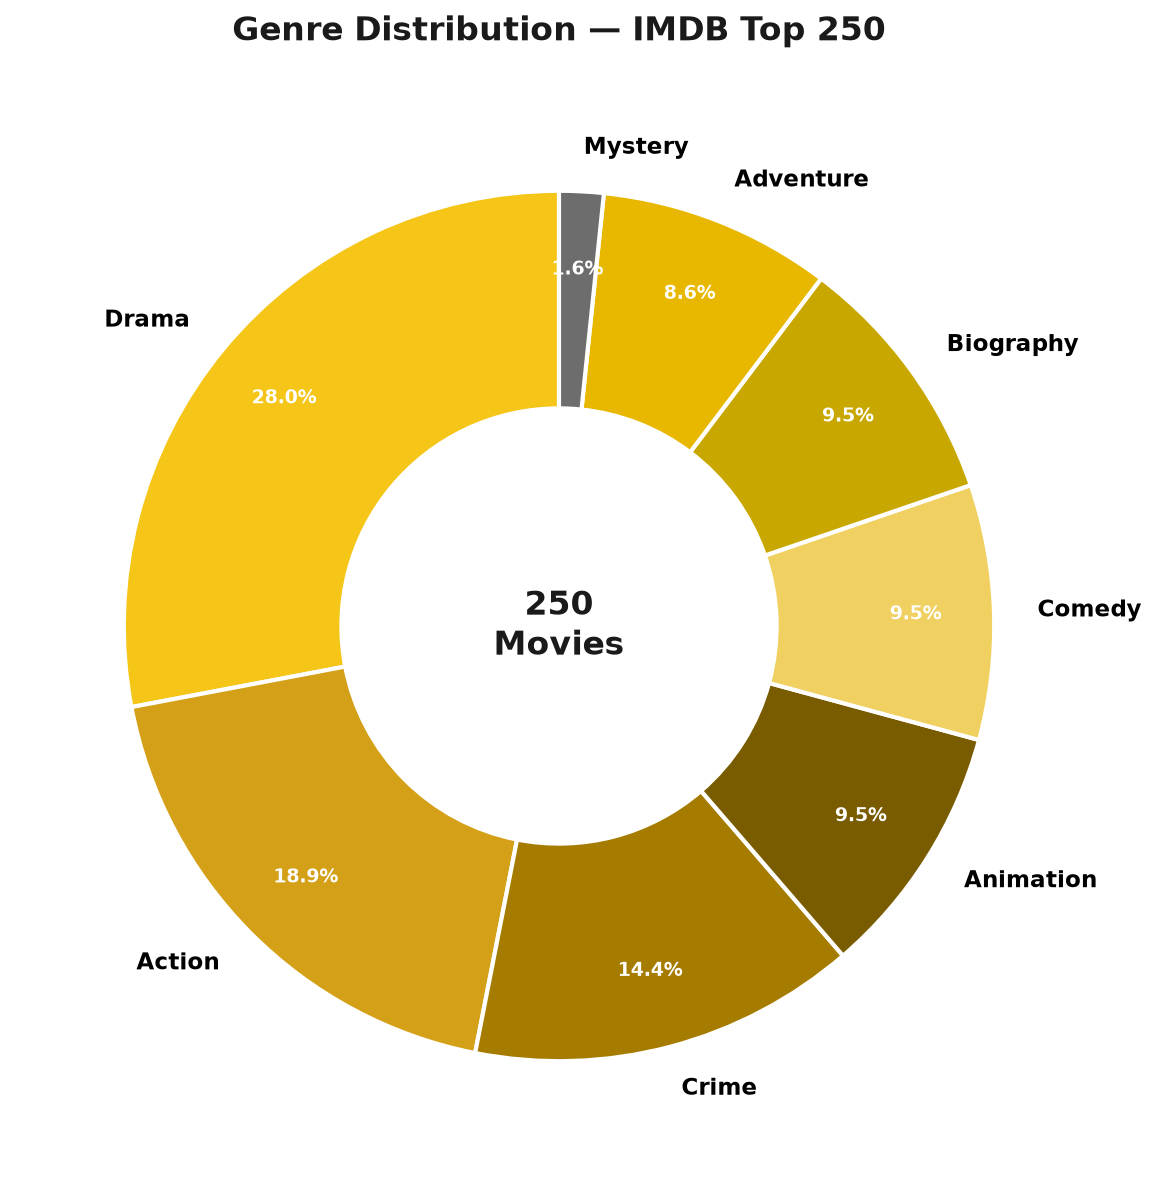

 Chart 2 saved!


In [4]:
# Chart 2 - Genre Donut Chart
fig, ax = plt.subplots(figsize=(10, 8))

genre_counts = df["Primary_Genre"].value_counts().head(8)

colors = [IMDB_YELLOW, "#D4A017", "#A67C00", "#7A5C00",
          "#F0D060", "#C8A800", "#E8B800", IMDB_GRAY]

wedges, texts, autotexts = ax.pie(
    genre_counts.values,
    labels      = genre_counts.index,
    autopct     = "%1.1f%%",
    colors      = colors,
    startangle  = 90,
    pctdistance = 0.82,
    wedgeprops  = {"width": 0.5, "edgecolor": "white", "linewidth": 2}
)

# Text styling
for text in texts:
    text.set_fontsize(11)
    text.set_fontweight("bold")
for autotext in autotexts:
    autotext.set_fontsize(9)
    autotext.set_color("white")
    autotext.set_fontweight("bold")

# Center text
ax.text(0, 0, "250\nMovies", ha="center", va="center",
        fontsize=16, fontweight="bold", color=IMDB_BLACK)

ax.set_title("Genre Distribution — IMDB Top 250",
             fontsize=16, fontweight="bold", pad=20, color=IMDB_BLACK)

plt.tight_layout()
plt.savefig("chart2_genre_donut.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Chart 2 saved!")

In [5]:
pip install scipy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


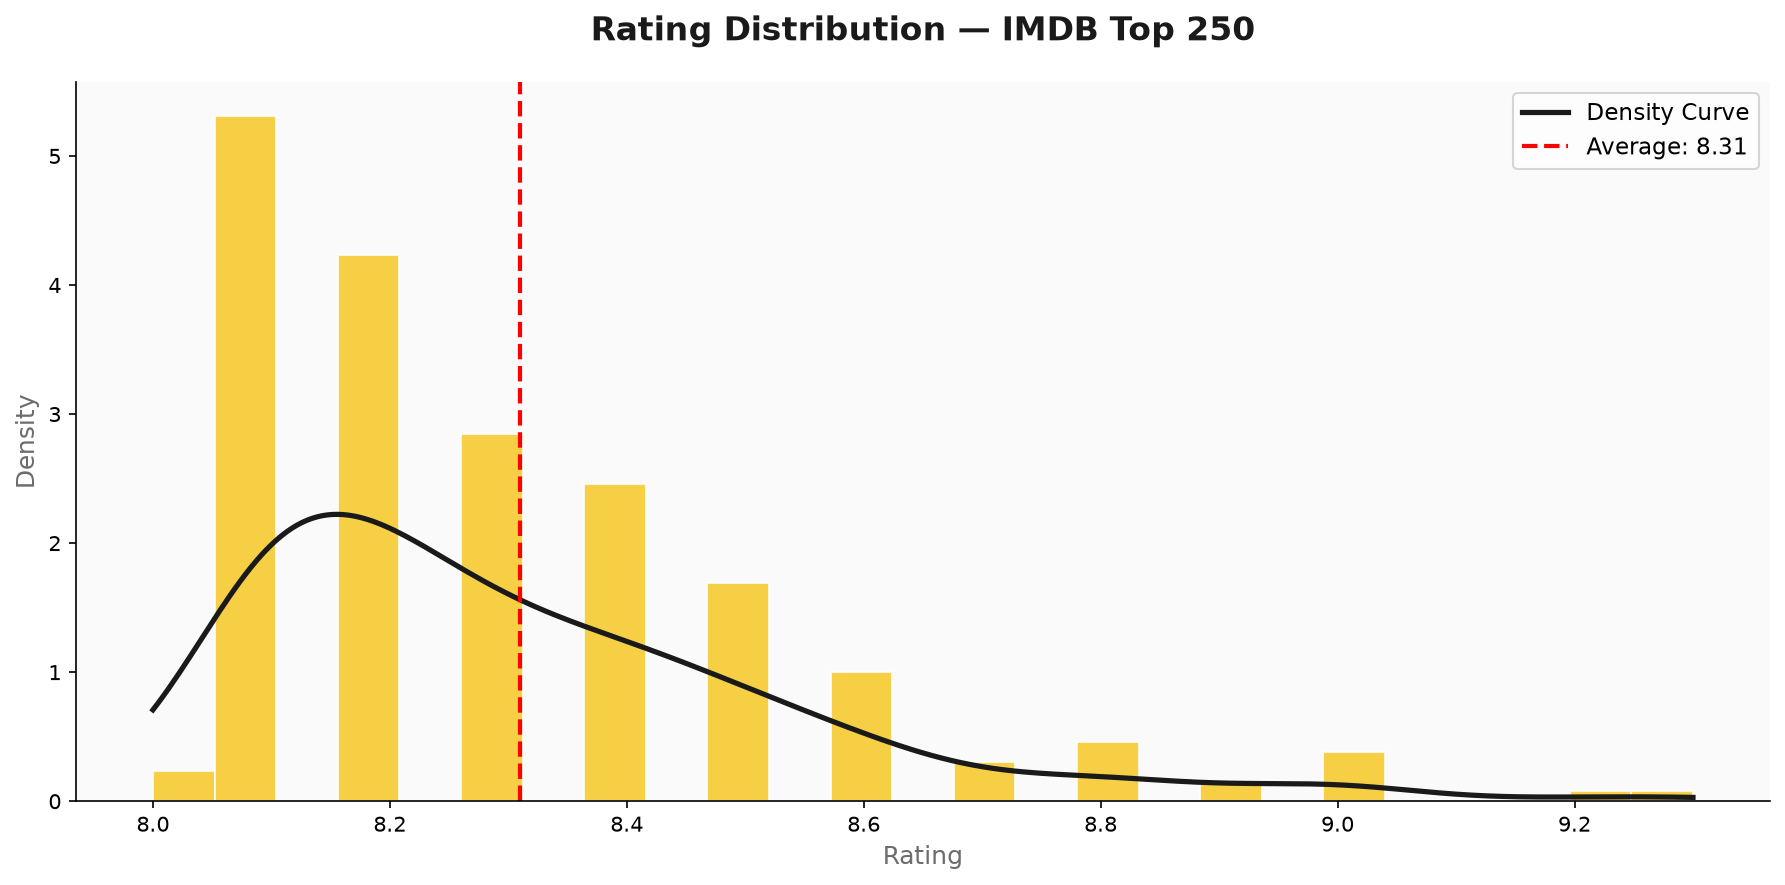

 Chart 3 saved!


In [6]:
# Chart 3 - Rating Distribution
fig, ax = plt.subplots(figsize=(12, 6))

# Histogram
ax.hist(df["Rating"], bins=25, color=IMDB_YELLOW, 
        edgecolor="white", alpha=0.8, density=True)

# KDE curve
from scipy.stats import gaussian_kde
kde_x = np.linspace(df["Rating"].min(), df["Rating"].max(), 300)
kde_y = gaussian_kde(df["Rating"])(kde_x)
ax.plot(kde_x, kde_y, color=IMDB_BLACK, linewidth=2.5, label="Density Curve")

# Average line
avg = df["Rating"].mean()
ax.axvline(avg, color="red", linewidth=2, linestyle="--", label=f"Average: {avg:.2f}")

# Styling
ax.set_title("Rating Distribution — IMDB Top 250",
             fontsize=16, fontweight="bold", pad=20, color=IMDB_BLACK)
ax.set_xlabel("Rating", fontsize=12, color=IMDB_GRAY)
ax.set_ylabel("Density", fontsize=12, color=IMDB_GRAY)
ax.legend(fontsize=11)
ax.set_facecolor("#FAFAFA")
fig.patch.set_facecolor("white")

plt.tight_layout()
plt.savefig("chart3_rating_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Chart 3 saved!")

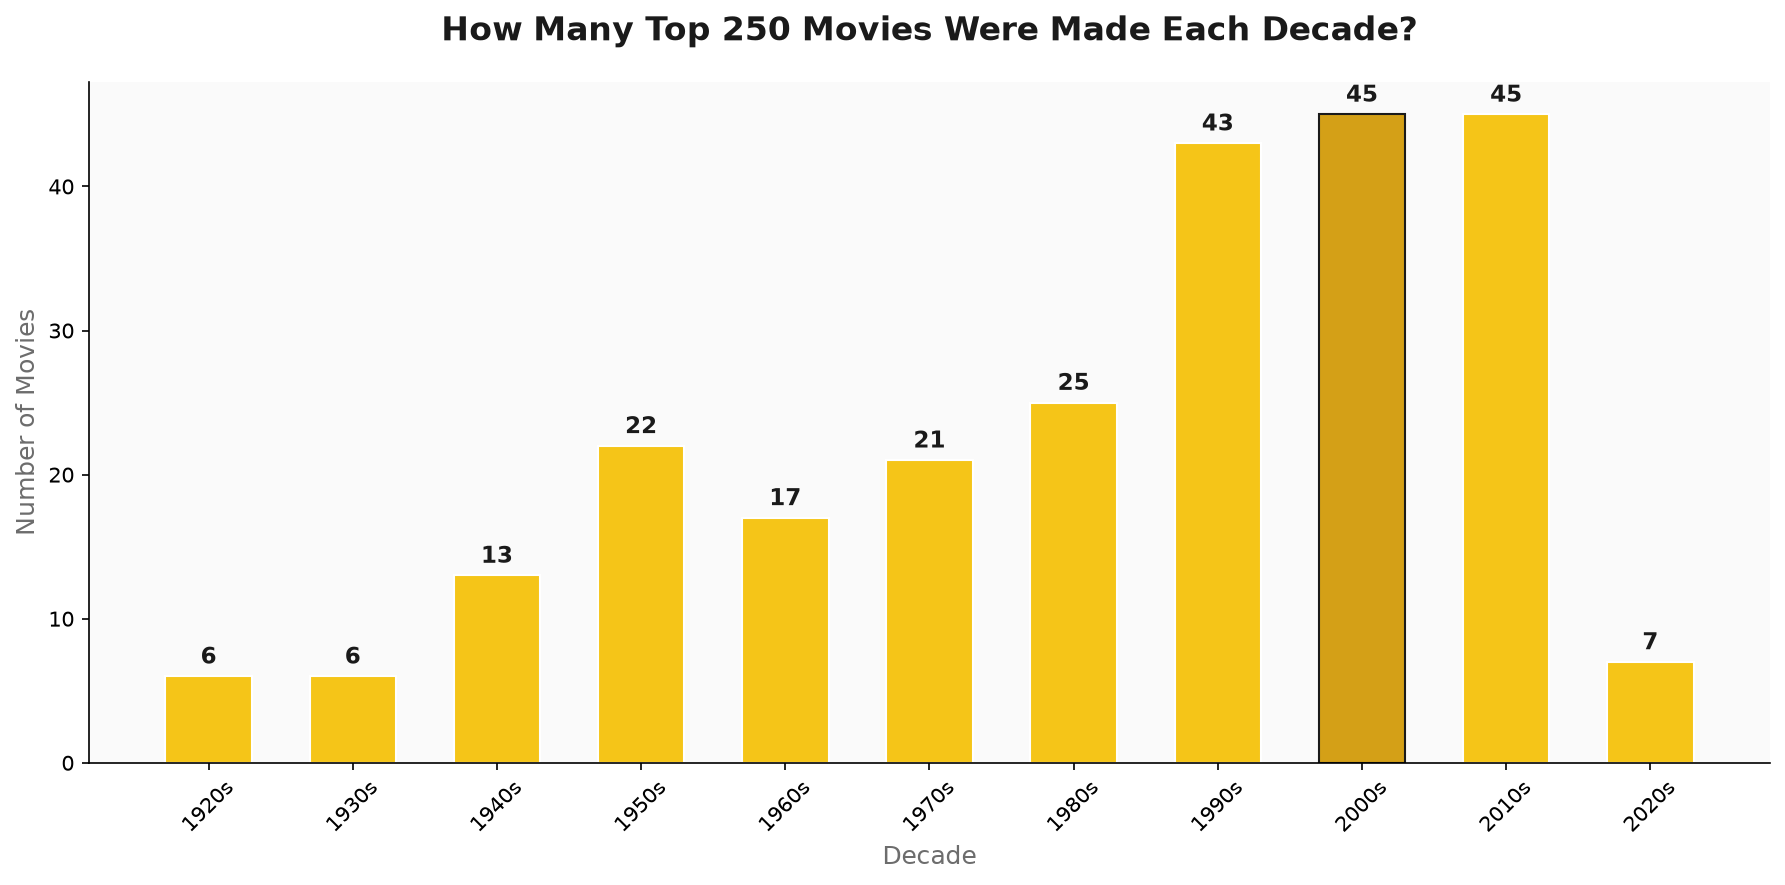

 Chart 4 saved!


In [7]:
# Chart 4 - Movies per Decade
fig, ax = plt.subplots(figsize=(12, 6))

decade_counts = df["Decade"].value_counts().sort_index()

# Bar chart
bars = ax.bar(decade_counts.index, decade_counts.values,
              color=IMDB_YELLOW, edgecolor="white", width=0.6)

# Value labels on top
for bar, val in zip(bars, decade_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(val), ha="center", va="bottom", 
            fontsize=11, fontweight="bold", color=IMDB_BLACK)

# Highlight best decade
max_idx = decade_counts.values.argmax()
bars[max_idx].set_color("#D4A017")
bars[max_idx].set_edgecolor(IMDB_BLACK)

# Styling
ax.set_title("How Many Top 250 Movies Were Made Each Decade?",
             fontsize=16, fontweight="bold", pad=20, color=IMDB_BLACK)
ax.set_xlabel("Decade", fontsize=12, color=IMDB_GRAY)
ax.set_ylabel("Number of Movies", fontsize=12, color=IMDB_GRAY)
ax.set_facecolor("#FAFAFA")
fig.patch.set_facecolor("white")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("chart4_movies_per_decade.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Chart 4 saved!")

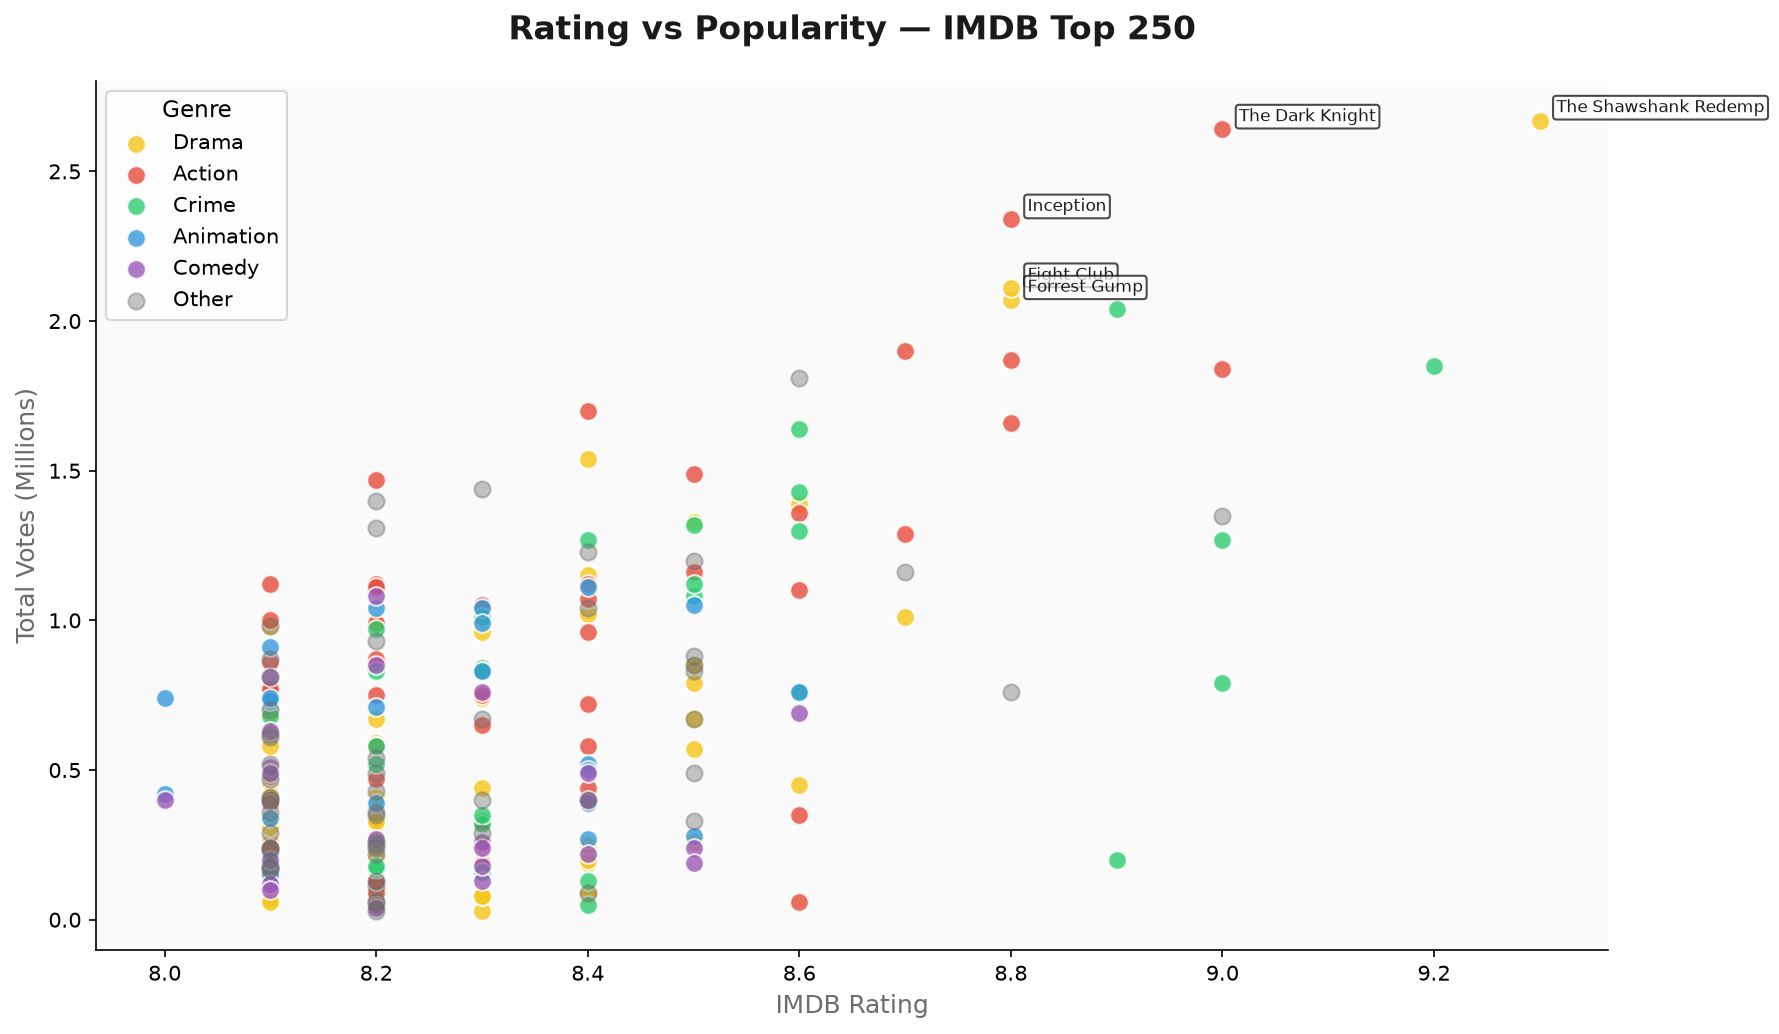

 Chart 5 saved!


In [8]:
# Chart 5 - Rating vs Votes Scatter Plot
fig, ax = plt.subplots(figsize=(12, 7))

# Genre ke hisaab se color
top5_genres = df["Primary_Genre"].value_counts().head(5).index
colors_map  = {
    "Drama"    : "#F5C518",
    "Action"   : "#E74C3C",
    "Crime"    : "#2ECC71",
    "Animation": "#3498DB",
    "Comedy"   : "#9B59B6"
}

for genre, color in colors_map.items():
    mask = df["Primary_Genre"] == genre
    ax.scatter(df[mask]["Rating"], df[mask]["Votes_M"],
               color=color, alpha=0.8, s=80, label=genre, edgecolors="white")

# Baki genres gray mein
other_mask = ~df["Primary_Genre"].isin(top5_genres)
ax.scatter(df[other_mask]["Rating"], df[other_mask]["Votes_M"],
           color=IMDB_GRAY, alpha=0.4, s=60, label="Other")

# Top 5 movies annotate karo
top5 = df.nlargest(5, "Votes_M")
for _, row in top5.iterrows():
    ax.annotate(row["Title"][:20],
                xy=(row["Rating"], row["Votes_M"]),
                xytext=(8, 4), textcoords="offset points",
                fontsize=8, color=IMDB_BLACK,
                bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7))

# Styling
ax.set_title("Rating vs Popularity — IMDB Top 250",
             fontsize=16, fontweight="bold", pad=20, color=IMDB_BLACK)
ax.set_xlabel("IMDB Rating", fontsize=12, color=IMDB_GRAY)
ax.set_ylabel("Total Votes (Millions)", fontsize=12, color=IMDB_GRAY)
ax.legend(title="Genre", fontsize=10, title_fontsize=11)
ax.set_facecolor("#FAFAFA")
fig.patch.set_facecolor("white")

plt.tight_layout()
plt.savefig("chart5_rating_vs_votes.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Chart 5 saved!")

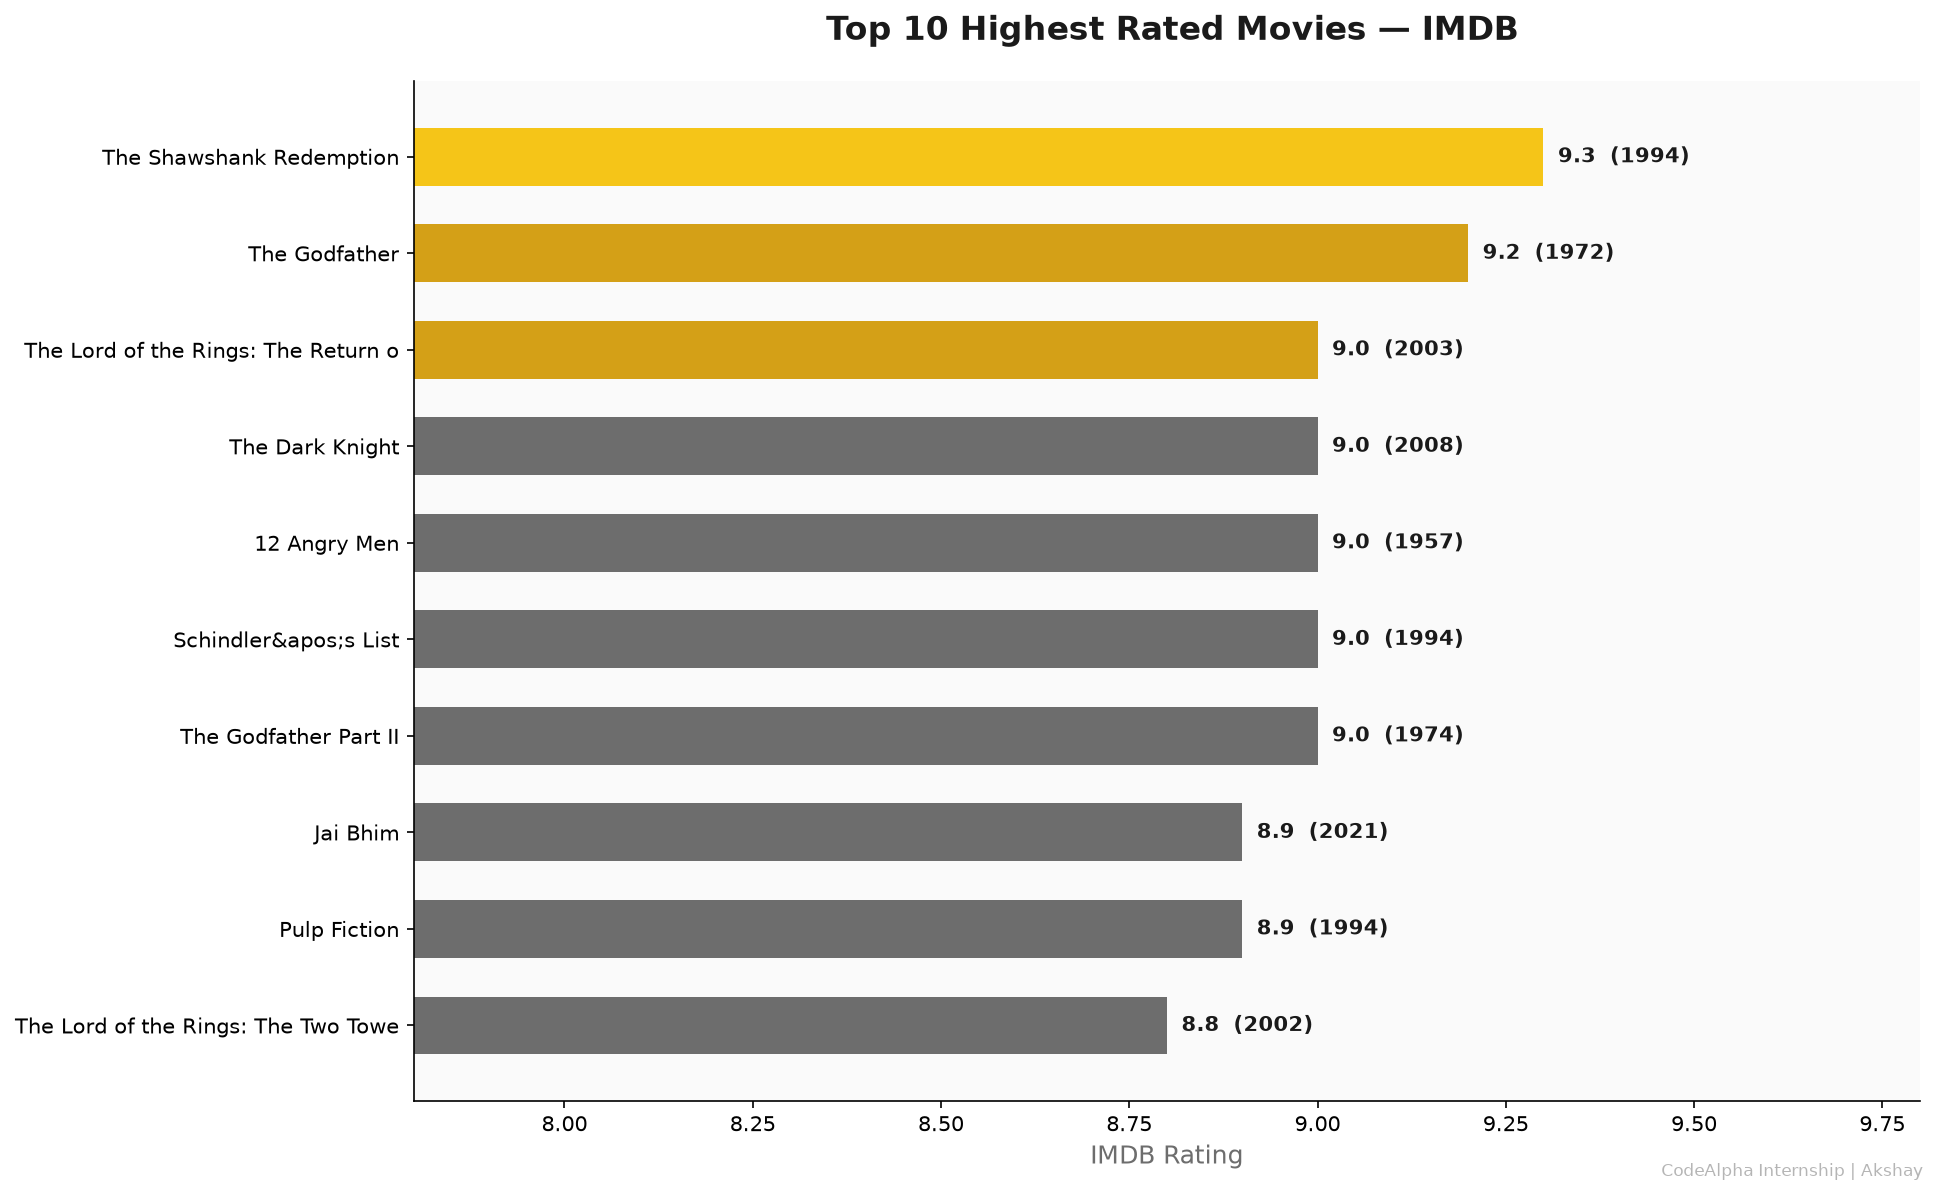

 Chart 6 saved!


In [9]:
# Chart 6 - Top 10 Movies by Rating (Hero Chart)
fig, ax = plt.subplots(figsize=(13, 8))

top10 = df.nlargest(10, "Rating").sort_values("Rating")

# Color — top movies
colors = [IMDB_YELLOW if i == 9 else "#D4A017" if i >= 7 else IMDB_GRAY
          for i in range(len(top10))]

bars = ax.barh(top10["Title"].str[:35], top10["Rating"],
               color=colors, edgecolor="none", height=0.6)

# Value + Year labels
for bar, (_, row) in zip(bars, top10.iterrows()):
    ax.text(bar.get_width() + 0.01,
            bar.get_y() + bar.get_height()/2,
            f" {row['Rating']}  ({int(row['Year'])})",
            va="center", fontsize=10, color=IMDB_BLACK, fontweight="bold")

# Styling
ax.set_title(" Top 10 Highest Rated Movies — IMDB",
             fontsize=16, fontweight="bold", pad=20, color=IMDB_BLACK)
ax.set_xlabel("IMDB Rating", fontsize=12, color=IMDB_GRAY)
ax.set_xlim(7.8, 9.8)
ax.set_facecolor("#FAFAFA")
fig.patch.set_facecolor("white")
ax.tick_params(axis="y", labelsize=10)

# Watermark
fig.text(0.99, 0.01, "CodeAlpha Internship | Akshay",
         ha="right", va="bottom", fontsize=8, color=IMDB_GRAY, alpha=0.5)

plt.tight_layout()
plt.savefig("chart6_top10_movies.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Chart 6 saved!")